In [7]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from sklearn.metrics import r2_score
import seaborn as sns
from datetime import datetime
from tabulate import tabulate
import pandas as pd

sns.set_theme(style='ticks', context='paper')

In [8]:
# Constants
ENERGY_CONSUMPTION = "Energy Consumption (exc. PUE)"
ENERGY_CONSUMPTION_PUE = "Energy Consumption (inc. PUE)"
MEMORY_CONSUMPTION = "Memory Energy Consumption (exc. PUE)"
MEMORY_CONSUMPTION_PUE = "Memory Energy Consumption (inc. PUE)"
CARBON_EMISSIONS = "Carbon Emissions"

In [9]:
# Trace File Paths List
workflows = ['chipseq', 'mag', 'montage', 'nanoseq', 'rangeland', 'rnaseq', 'sarek']
regions = ['Great Britain']#, 'Germany', 'California', 'Texas', 'South Africa', 'Tokyo', 'New South Wales']
short_regions = ['gb']#, 'de', 'ca', 'tx', 'zaf', 'tyo', 'nsw']
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
short_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] 
month_dates = ['08012024-13012024', '12022024-17022024', '11032024-16032024',  
    '08042024-13042024', '13052024-18052024', '10062024-15062024',  
    '08072024-13072024', '12082024-17082024', '09092024-14092024',  
    '14102024-19102024', '11112024-16112024', '09122024-14122024']
region_folders = [f'../data/results/interrupt-wf-shifting/out/{region}/' for region in short_regions]
windows = [6, 12, 24, 48, 96]

In [10]:
def get_max_overhead(overheads):
    oh_1, _ = overheads[0].split('|')
    oh_2, _ = overheads[1].split('|')
    oh_3, _ = overheads[2].split('|')

    return max([float(oh_1), float(oh_2), float(oh_3)])
    

def parse_ts_summary_file(file):
    with open(file, 'r') as f:
        lines = f.readlines()[1:]

    props = {}

    for line in lines:
        parts = line.split(',')
        workflow = parts[0].split('-')[0]
        footprint = float(parts[1])
        makespan = float(parts[2])
        entry_6h = parts[3].split(':')
        entry_12h = parts[4].split(':')
        entry_24h = parts[5].split(':')
        entry_48h = parts[6].split(':')
        entry_96h = parts[7].split(':')

        if len(props) == 0:
            props = {
                "FOOTPRINT": [footprint],
                "MAKESPAN": [makespan],
                "6H_FOOTPRINT": [float(entry_6h[1])],
                "6H_REDUCTION": [float(entry_6h[0][:-1])],
                "6H_OVERHEAD": [entry_6h[2]],
                "12H_FOOTPRINT": [float(entry_12h[1])],
                "12H_REDUCTION": [float(entry_12h[0][:-1])],
                "12H_OVERHEAD": [entry_12h[2]],
                "24H_FOOTPRINT": [float(entry_24h[1])],
                "24H_REDUCTION": [float(entry_24h[0][:-1])],
                "24H_OVERHEAD": [entry_24h[2]],
                "48H_FOOTPRINT": [float(entry_48h[1])],
                "48H_REDUCTION": [float(entry_48h[0][:-1])],
                "48H_OVERHEAD": [entry_48h[2]],
                "96H_FOOTPRINT": [float(entry_96h[1])],
                "96H_REDUCTION": [float(entry_96h[0][:-1])],
                "96H_OVERHEAD": [entry_96h[2]]
            }
        else: 
            props["FOOTPRINT"].append(footprint)
            props["MAKESPAN"].append(makespan)
            props["6H_FOOTPRINT"].append(float(entry_6h[1]))
            props["6H_REDUCTION"].append(float(entry_6h[0][:-1]))
            props["6H_OVERHEAD"].append(entry_6h[2])
            props["12H_FOOTPRINT"].append(float(entry_12h[1]))
            props["12H_REDUCTION"].append(float(entry_12h[0][:-1]))
            props["12H_OVERHEAD"].append(entry_12h[2])
            props["24H_FOOTPRINT"].append(float(entry_24h[1]))
            props["24H_REDUCTION"].append(float(entry_24h[0][:-1]))
            props["24H_OVERHEAD"].append(entry_24h[2])
            props["48H_FOOTPRINT"].append(float(entry_48h[1]))
            props["48H_REDUCTION"].append(float(entry_48h[0][:-1]))
            props["48H_OVERHEAD"].append(entry_48h[2])
            props["96H_FOOTPRINT"].append(float(entry_96h[1]))
            props["96H_REDUCTION"].append(float(entry_96h[0][:-1]))
            props["96H_OVERHEAD"].append(entry_96h[2])

    data = {}
    wf_makespan = sum(props["MAKESPAN"]) / 3
    footprint_6h = sum(props["6H_FOOTPRINT"]) / 3
    reduction_6h = sum(props["6H_REDUCTION"]) / 3
    max_overhead_6h = get_max_overhead(props["6H_OVERHEAD"])
    footprint_12h = sum(props["12H_FOOTPRINT"]) / 3
    reduction_12h = sum(props["12H_REDUCTION"]) / 3

    if reduction_12h < reduction_6h:
        reduction_12h = reduction_6h

    max_overhead_12h = get_max_overhead(props["12H_OVERHEAD"])
    footprint_24h = sum(props["24H_FOOTPRINT"]) / 3
    reduction_24h = sum(props["24H_REDUCTION"]) / 3

    if reduction_24h < reduction_12h:
        reduction_24h = reduction_12h

    max_overhead_24h = get_max_overhead(props["24H_OVERHEAD"])
    footprint_48h = sum(props["48H_FOOTPRINT"]) / 3
    reduction_48h = sum(props["48H_REDUCTION"]) / 3

    if reduction_48h < reduction_24h:
        reduction_48h = reduction_24h

    max_overhead_48h = get_max_overhead(props["48H_OVERHEAD"])
    footprint_96h = sum(props["96H_FOOTPRINT"]) / 3
    reduction_96h = sum(props["96H_REDUCTION"]) / 3

    if reduction_96h < reduction_48h:
        reduction_96h = reduction_48h

    max_overhead_96h = get_max_overhead(props["6H_OVERHEAD"])

    data = {
        "FOOTPRINT": sum(props["FOOTPRINT"]) / 3,
        "MAKESPAN": wf_makespan,
        "6H_REDUCTION": reduction_6h,
        "6H_OVERHEAD":  max_overhead_6h,
        "6H_FOOTPRINT": footprint_6h,
        "12H_REDUCTION":  reduction_12h,
        "12H_OVERHEAD":  max_overhead_12h,
        "12H_FOOTPRINT": footprint_12h,
        "24H_REDUCTION":  reduction_24h,
        "24H_OVERHEAD":  max_overhead_24h,
        "24H_FOOTPRINT": footprint_24h,
        "48H_REDUCTION":  reduction_48h,
        "48H_OVERHEAD":  max_overhead_48h,
        "48H_FOOTPRINT": footprint_48h,
        "96H_REDUCTION":  reduction_96h,
        "96H_OVERHEAD":  max_overhead_96h,
        "96H_FOOTPRINT": footprint_96h,
    }

    return data
        

In [11]:
def write_to_file(outfile, data, headers):
    with open(f'../data/results/interrupt-wf-shifting/out/{outfile}', 'w') as f:
        f.write(','.join(headers) + '\n')

        for row in data:
            f.write(','.join(row) + '\n')

# purpose illustrating impact of pausing on overall footprint
- here, we consider the overhead in seconds, and convert this to a time in h
- we use this time to then account for memory energy consumption, where this considers all of the memory in the nodes used
- e.g. 256GB on all 8 nodes, assuming that data is stored here for time spent waiting (the overhead)
- this used the constant 0.392W/GB [[WHAT ARE THE STORAGE COSTS? disks/ssds (lookup)]], and average CI data from 2023 UK -- 215gCO2e
  - disk embodied emissions (Youssef?)
  - stored energy costs (pick upper bound of intermediate storage? total bytes written/read?)
>> 2024 United States Data Center Energy Usage Report
    - https://escholarship.org/uc/item/32d6m0d1
    - has some broad figures e.g. 11W/6W/6.5W/disk (how big is the disk, how many disk, how does this occur over time?)
>> Energy-aware operation of HPC systems in Germany
    - https://www.frontiersin.org/journals/high-performance-computing/articles/10.3389/fhpcp.2025.1520207/full (to be read)
- here, we see that there is little change to the overall reduction in footprint, with minimal emissions added on

nanoseq server -- 512GB SSD
hu cluster -- 2 x 3.5 TB SSD (ask for more info?)
tu cluster -- 2 SATA III SSDs with 960GB

In [12]:
# Interrupting Footprints - Average CI
headers = ["Region", "Month", "Workflow", "Original Footprint (gCO2e)", "Makespan (s)", 
           "Reduction 6h (%)", "Overhead 6h", "FP 6h",
           "Reduction 12h (%)", "Overhead 12h", "FP 12h",
           "Reduction 24h (%)", "Overhead 24h", "FP 24h",
           "Reduction 48h (%)", "Overhead 48h", "FP 48h",
           "Reduction 96h (%)","Overhead 96h", "FP 96h"]
data_avg_tbl = []
data_avg_dct = {}

for region, region_base in zip(short_regions, region_folders):
    if region not in data_avg_dct:
        data_avg_dct[region] = {}
    for month in short_months:
        for workflow in workflows:
            if workflow not in data_avg_dct[region]:
                data_avg_dct[region][workflow] = {}
            if month not in data_avg_dct[region][workflow]:
                data_avg_dct[region][workflow][month] = {} 
            temp = parse_ts_summary_file(f'{region_base}{workflow}-{month}-avg-ts.csv')
            span = temp["MAKESPAN"]
            data_avg_tbl.append([region, month, workflow,f'{temp["FOOTPRINT"]:.2f}', f'{span:.0f}', 
                 f"{temp['6H_REDUCTION']:.2f}", f"{temp['6H_OVERHEAD']:.2f}", f"{temp['6H_FOOTPRINT']:.2f}",
                 f"{temp['12H_REDUCTION']:.2f}", f"{temp['12H_OVERHEAD']:.2f}", f"{temp['12H_FOOTPRINT']:.2f}",
                 f"{temp['24H_REDUCTION']:.2f}", f"{temp['24H_OVERHEAD']:.2f}", f"{temp['24H_FOOTPRINT']:.2f}",
                 f"{temp['48H_REDUCTION']:.2f}", f"{temp['48H_OVERHEAD']:.2f}", f"{temp['48H_FOOTPRINT']:.2f}",
                 f"{temp['96H_REDUCTION']:.2f}", f"{temp['96H_OVERHEAD']:.2f}", f"{temp['96H_FOOTPRINT']:.2f}"])

            data_avg_dct[region][workflow][month][6] = temp['6H_REDUCTION']
            data_avg_dct[region][workflow][month][12] = temp['12H_REDUCTION']
            data_avg_dct[region][workflow][month][24] = temp['24H_REDUCTION']
            data_avg_dct[region][workflow][month][48] = temp['48H_REDUCTION']
            data_avg_dct[region][workflow][month][96] = temp['96H_REDUCTION']


# Accounting Example (marginal doesn't make much sense -- this is for the discussion)
limited_df = pd.DataFrame.from_records(data_avg_tbl, columns=headers)
limited_df = limited_df.drop(columns=['Region', 'Month'])
limited_df['OrFP'] = limited_df['Original Footprint (gCO2e)'].astype(float)
limited_df['span_s'] = limited_df['Makespan (s)'].astype(float)
limited_df['red_6h_per'] = limited_df['Reduction 6h (%)'].astype(float)
limited_df['red_12h_per'] = limited_df['Reduction 12h (%)'].astype(float)
limited_df['red_24h_per'] = limited_df['Reduction 24h (%)'].astype(float)
limited_df['red_48h_per'] = limited_df['Reduction 48h (%)'].astype(float)
limited_df['red_96h_per'] = limited_df['Reduction 96h (%)'].astype(float)
limited_df['oh_6h_s'] = limited_df['Overhead 6h'].astype(float)
limited_df['oh_12h_s'] = limited_df['Overhead 12h'].astype(float)
limited_df['oh_24h_s'] = limited_df['Overhead 24h'].astype(float)
limited_df['oh_48h_s'] = limited_df['Overhead 48h'].astype(float)
limited_df['oh_96h_s'] = limited_df['Overhead 96h'].astype(float)
limited_df['fp_6h'] = limited_df['FP 6h'].astype(float)
limited_df['fp_12h'] = limited_df['FP 12h'].astype(float)
limited_df['fp_24h'] = limited_df['FP 24h'].astype(float)
limited_df['fp_48h'] = limited_df['FP 48h'].astype(float)
limited_df['fp_96h'] = limited_df['FP 96h'].astype(float)
avg = limited_df.groupby(['Workflow']).mean(numeric_only=True).reset_index()

for workflow, node_mem, nodes in zip(workflows, [128, 256, 128, 32, 256, 128, 128], [8, 8, 8, 1, 8, 8, 8]):
    row = avg[avg['Workflow'] == workflow].iloc[0].to_dict()
    # mem_oh_24h_energy = node_mem * nodes * 0.392 * (row['oh_24h_s'] / 3600) * 0.001  # convert from W to kW
    # mem_oh_24h_ems = mem_oh_24h_energy * 215
    # tot_24h_ems = mem_oh_24h_ems + row['fp_24h']
    # mem_oh_96h_energy = node_mem * nodes * 0.392 * (row['oh_96h_s'] / 3600) * 0.001  # convert from W to kW
    # mem_oh_96h_ems = mem_oh_96h_energy * 215
    # tot_96h_ems = mem_oh_96h_ems + row['fp_96h']

    print(f'{workflow} Original Footprint [{row['OrFP']:.2f}gCO2e] Makespan [{row['span_s'] / 3600:.2f}h] Overhead 24h [{row['oh_24h_s'] / 3600:.2f}h] Overhead 96h [{row['oh_96h_s'] / 3600:.2f}h]')
    # print(f'24H Overhead {mem_oh_24h_ems:.2f}gCO2e Total {tot_24h_ems:.2f}gCO2e Reduction {(row['OrFP'] - tot_24h_ems) /  row['OrFP'] * 100:.2f}% prev. {row['red_24h_per']:.2f}%')
    # print(f'96h Overhead {mem_oh_96h_ems:.2f}gCO2e Total {tot_96h_ems:.2f}gCO2e Reduction {(row['OrFP'] - tot_96h_ems) / row['OrFP'] * 100:.2f}% prev. {row['red_96h_per']:.2f}%')
    # re ichnos, National Grid Average CI in 2023 is 215gCO2e (rough estimation)


chipseq Original Footprint [933.42gCO2e] Makespan [3.70h] Overhead 24h [0.05h] Overhead 96h [0.03h]
mag Original Footprint [2787.17gCO2e] Makespan [12.63h] Overhead 24h [0.77h] Overhead 96h [0.73h]
montage Original Footprint [53.11gCO2e] Makespan [0.53h] Overhead 24h [0.00h] Overhead 96h [0.00h]
nanoseq Original Footprint [47.48gCO2e] Makespan [5.56h] Overhead 24h [0.11h] Overhead 96h [0.02h]
rangeland Original Footprint [1345.35gCO2e] Makespan [6.89h] Overhead 24h [0.05h] Overhead 96h [0.03h]
rnaseq Original Footprint [671.18gCO2e] Makespan [3.06h] Overhead 24h [0.13h] Overhead 96h [0.13h]
sarek Original Footprint [1203.44gCO2e] Makespan [5.07h] Overhead 24h [0.33h] Overhead 96h [0.06h]


In [13]:
# Constants
regions = ['Great Britain', 'Germany', 'California', 'Texas', 'South Africa', 'Tokyo', 'New South Wales']
short_regions = ['gb', 'de', 'ca', 'tx', 'zaf', 'tyo', 'nsw']
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
short_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] 
month_dates = ['08012024-13012024', '12022024-17022024', '11032024-16032024',  
    '08042024-13042024', '13052024-18052024', '10062024-15062024',  
    '08072024-13072024', '12082024-17082024', '09092024-14092024',  
    '14102024-19102024', '11112024-16112024', '09122024-14122024']
region_folders = [f'../data/results/entire-wf-shifting/out-err/{region}/' for region in short_regions]
workflows=['chipseq', 'mag', 'montage', 'nanoseq', 'rangeland', 'rnaseq', 'sarek']

In [14]:
# Parse Explorer Summary (NEW)
def parse_explorer_summary(explorer_data):
    with open(explorer_data, 'r') as f:
        data = [line.strip().split(',') for line in f.readlines()]

    for row in data:
        if '~' in row[0]:
            shift_ms = row[0].split('~')[1][:-4]
            days = int(shift_ms.split('-')[0])
            hours = int(shift_ms.split('-')[1])
            shift_h = (days * 24) + hours
            row[0] = shift_h
        else:
            row[0] = 0

    data_d = {}

    for row in data:
        data_d[row[0]] = {'emissions': row[1]}

    return data_d


def get_minimum(data):
    minimum = float(data[0]['emissions'])
    shift = 0

    for key, entry in data.items():
        if float(entry['emissions']) < minimum:
            minimum = float(entry['emissions'])
            shift = key

    return (shift, minimum)


def get_reduction(original, new):
    orig = float(original)
    neww = float(new)
    return ((orig - neww) / abs(orig)) * 100


def overview(trace, print=False):
    data = parse_explorer_summary(trace)
    (min_shift, min_emissions) = get_minimum(data)

    if print:
        print(f"Original [0] CCF {data[0]['emissions']} gCO2e")  # original
        print(f"Minimum [{min_shift}] CCF {min_emissions} gCO2e")  # minimum
        print(f"Reduction {get_reduction(data[0]['emissions'], min_emissions):.2f}%")

    return (data, min_shift, min_emissions)


def average(arr):
    return sum([float(val) for val in arr]) / len(arr)

In [15]:
# Parse Readings for all readings, through the year
def parse_readings(window, marg='', err='', region='gb', folder=f'../data/results/entire-wf-shifting/out-err/{region}/'):
    if err == '':
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{region}-{month_dates[i]}{err}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{region}-{month_dates[i]}{err}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{region}-{month_dates[i]}{err}{marg}~footprint.csv'

                (data_1, _, min_emissions_1) = overview(path_one)
                (data_2, _, min_emissions_2) = overview(path_two)
                (data_3, _, min_emissions_3) = overview(path_three)
                avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions']])
                avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3])
                avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]

        return reduction_by_workflow

    data = {}

    for rep in range(1, 6):
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{region}-{month_dates[i]}{err}-{rep}{marg}~footprint.csv'

                (data_1, _, min_emissions_1) = overview(path_one)
                (data_2, _, min_emissions_2) = overview(path_two)
                (data_3, _, min_emissions_3) = overview(path_three)
                avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions']])
                avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3])
                avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]
    
        data[rep] = reduction_by_workflow

    return data

## Sensitivity Analysis
- think it's a logical assumption to be like, yes the method is dependent on the quality of the forecast
  - only real signal we have to go off
  - as they become more accurate, so do the potential reductions

In [16]:
## Sensitivity Analysis - CI Experiments [24: 5, 10, 15 ~~ 96: 5, 10, 15]
region = 'gb'

# Average CI (24h)
read_24h = parse_readings(window=24)
curr = []
for workflow in workflows:
    curr.append(read_24h[workflow])
reads_24h_original = np.array(curr)

# Error 5% (24h)
reads_24h_err5 = parse_readings(window=24, err='-err5')
all_reads_24h_err5 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err5[iter][workflow])
    all_reads_24h_err5.append(np.array(curr))
reads_24h_err5_mean = np.mean(all_reads_24h_err5, axis=0)

# Error 10% (24h)
reads_24h_err10 = parse_readings(window=24, err='-err10')
all_reads_24h_err10 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err10[iter][workflow])
    all_reads_24h_err10.append(np.array(curr))
reads_24h_err10_mean = np.mean(all_reads_24h_err10, axis=0)

# Error 15% (24h)
reads_24h_err15 = parse_readings(window=24, err='-err15')
all_reads_24h_err15 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24h_err15[iter][workflow])
    all_reads_24h_err15.append(np.array(curr))
reads_24h_err15_mean = np.mean(all_reads_24h_err15, axis=0)

# Average CI (96h)
read_96h = parse_readings(window=96)
curr = []
for workflow in workflows:
    curr.append(read_96h[workflow])
reads_96h_original = np.array(curr)

# Error 5% (24h)
reads_96h_err5 = parse_readings(window=96, err='-err5')
all_reads_96h_err5 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err5[iter][workflow])
    all_reads_96h_err5.append(np.array(curr))
reads_96h_err5_mean = np.mean(all_reads_96h_err5, axis=0)

# Error 10% (96h)
reads_96h_err10 = parse_readings(window=96, err='-err10')
all_reads_96h_err10 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err10[iter][workflow])
    all_reads_96h_err10.append(np.array(curr))
reads_96h_err10_mean = np.mean(all_reads_96h_err10, axis=0)

# Error 15% (96h)
reads_96h_err15 = parse_readings(window=96, err='-err15')
all_reads_96h_err15 = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96h_err15[iter][workflow])
    all_reads_96h_err15.append(np.array(curr))
reads_96h_err15_mean = np.mean(all_reads_96h_err15, axis=0)

def summarise(orig, err, err_v):
    print(f'Comparison using {err_v}% with CI Forecast')

    orig_total = 0
    for workflow, i in zip(workflows, range(0, 7)):
        orig_total += np.average(orig[i])

    total = 0
    for workflow, i in zip(workflows, range(0, 7)):
        # print(f'[{workflow}] mean reduction: {np.average(orig[i]):.2f}% 5err: {np.average(err[i]):.2f}%')
        total += np.average(np.average(err[i]))

    print(f'Mean Reduction (orig): {orig_total / 7:.2f}%')
    print(f'Mean Reduction ({err_v}%): {total / 7:.2f}%')

    return (orig_total / 7, total / 7)

In [17]:
res_24_5 = summarise(reads_24h_original, reads_24h_err5_mean, '(24h) 5')
print('---')
res_96_5 = summarise(reads_96h_original, reads_96h_err5_mean, '(96h) 5')

Comparison using (24h) 5% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 5%): 34.24%
---
Comparison using (96h) 5% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 5%): 44.00%


In [18]:
res_24_10 = summarise(reads_24h_original, reads_24h_err10_mean, '(24h) 10')
print('---')
res_96_10 = summarise(reads_96h_original, reads_96h_err10_mean, '(96h) 10')

Comparison using (24h) 10% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 10%): 34.88%
---
Comparison using (96h) 10% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 10%): 45.38%


In [19]:
res_24_15 = summarise(reads_24h_original, reads_24h_err15_mean, '(24h) 15')
print('---')
res_96_15 = summarise(reads_96h_original, reads_96h_err15_mean, '(96h) 15')

Comparison using (24h) 15% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 15%): 35.97%
---
Comparison using (96h) 15% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 15%): 47.75%


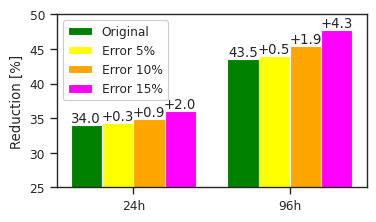

In [45]:
fig, ax = plt.subplots(figsize=(4,2.25))

# orig 24
width = 0.05
padding = 0.03
x = 2
y = 2.25

# 24h
orig_24 = ax.bar(x - width * 1.5, res_24_5[0], width, label='Original', color='green')
bar_24_5 = ax.bar(x - width * 0.5, res_24_5[1], width, label='Error 5%', color='yellow')
bar_24_10 = ax.bar(x + width * 0.5, res_24_10[1], width, label='Error 10%', color='orange')
bar_24_15 = ax.bar(x + width * 1.5, res_24_15[1], width, label='Error 15%', color='magenta')

ax.bar_label(orig_24, labels=[f'{round(res_24_5[0], 1)}'])
ax.bar_label(bar_24_5, labels=[f'+{round(res_24_5[1] - res_24_5[0], 1)}'])
ax.bar_label(bar_24_10, labels=[f'+{round(res_24_10[1] - res_24_5[0], 1)}'])
ax.bar_label(bar_24_15, labels=[f'+{round(res_24_15[1] - res_24_5[0], 1)}'])

# 96h
orig_96 = ax.bar(y - width * 1.5, res_96_5[0], width, label='Original', color='green')
bar_96_5 = ax.bar(y - width * 0.5, res_96_5[1], width, label='Error 5%', color='yellow')
bar_96_10 = ax.bar(y + width * 0.5, res_96_10[1], width, label='Error 10%', color='orange')
bar_96_15 = ax.bar(y + width * 1.5, res_96_15[1], width, label='Error 15%', color='magenta')

ax.bar_label(orig_96, labels=[f'{round(res_96_5[0], 1)}'])
ax.bar_label(bar_96_5, labels=[f'+{round(res_96_5[1] - res_96_5[0], 1)}'])
ax.bar_label(bar_96_10, labels=[f'+{round(res_96_10[1] - res_96_5[0], 1)}'])
ax.bar_label(bar_96_15, labels=[f'+{round(res_96_15[1] - res_96_5[0], 1)}'])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', ncols=1, framealpha=1)

xticks = [x, y]
xlabels = ['24h', '96h']
ax.set_xticks(xticks, xlabels)
ax.set_ylabel('Reduction [%]')
ax.set_ylim(25,50)

plt.savefig(f'../image/ci-sensitivity-analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Workflow read and write bytes
def get_read_write_workflow(workflow, iteration):
    with open(f'../data/traces/workflows/{workflow}/{workflow}-{iteration}.csv', 'r') as file:
        lines = file.readlines()[1:]

    read = 0
    write = 0

    for line in lines:
        parts = line.split(',')
        try:
            read += float(parts[32].strip())
            write += float(parts[33].strip())
        except ValueError:
            read += 0
            write += 0

    read /= 1073741824  # convert B to GB
    write /= 1073741824  # convert B to GB

    return (read, write)

def read_file_get_day(file, day):
    with open(f'../data/intensity/out/gb-{file}.csv', 'r') as file:
        raw = file.readlines()[1:]

    map = {}
    for line in raw:
        parts = line.split(',')
        if parts[0] == day:
            map[int(parts[1].split(':')[0])] = float(parts[2])
    
    return map

def min_consecutive_window(data, n):
    min_sum = float("inf")
    min_start = None

    for start in range(0, len(data) - n + 1):
        window_sum = sum(data[i] for i in range(start, start + n))

        if window_sum < min_sum:
            min_sum = window_sum
            min_start = start

    return {
        "start": min_start,
        "end": min_start + n - 1,
        "sum": min_sum,
        "values": {i: data[i] for i in range(min_start, min_start + n)}
    }

def weighted_sum(values, start_index, end_index, arr):
    return sum(
        arr[i] * values[start_index + i]
        for i in range(end_index - start_index)
    )

In [22]:
# Additional Experiment for Interrupted Shifting - acquire data for disk size (worst case scenario)

read_all = []
write_all = []

for workflow in workflows:
    r, w = get_read_write_workflow(workflow, 1)
    print(workflow, round(r, 2), 'GB', round(w, 2), 'GB')
    read_all.append(r)
    write_all.append(w)

max_read = max(read_all)
max_write = max(write_all)

print('max read', max_read, 'GB, max write', max_write, 'GB')
# test with both read and write
# whole drive draw = hours waited * disk wattage
# how to get hours waited, well, look at the interrupted shifting, look at the CI keys, and calculate the total gap in hours
# time distance tbc
# multiply (value / disk capacity) with whole drive draw
# = disk power draw for workflow
# represent as additional % of energy draw
# use same share value of embodied carbon emissions
# could use an average figure 2023 data CI for the carbon emissions, but energy should be sufficient ?


chipseq 226.46 GB 1234.92 GB
mag 36.02 GB 7010.67 GB
montage 0.0 GB 168.8 GB
nanoseq 69.85 GB 0.0 GB
rangeland 8.32 GB 253.54 GB
rnaseq 700.49 GB 1355.35 GB
sarek 685.71 GB 1976.02 GB
max read 700.4939384460449 GB, max write 7010.6672439575195 GB


In [23]:
# calculate average data per region? average hours waited per window, and number of pauses
# use values to estimate disk energy consumption and additional footprint? 

In [24]:
day = read_file_get_day('08042024-13042024', '2024-04-11')
best_5 = min_consecutive_window(day, 5)
best_6 = min_consecutive_window(day, 6)
workflow_even = [1, 1, 1, 1, 1]
print('original fp', weighted_sum(day, 1, 5, workflow_even))

print('predicted 5h (actual)')
print(best_5['start'], '-', best_5['end'])
print('even', weighted_sum(day, best_5['start'], best_5['start'] + 4, workflow_even))

print('predicted 6h')
print(best_6['start'], '-', best_6['end'])
print('even', weighted_sum(day, best_6['start'], best_6['start'] + 4, workflow_even))



original fp 186.29
predicted 5h (actual)
10 - 14
even 166.08
predicted 6h
9 - 14
even 181.06


In [25]:
# Parse Readings for all readings, through the year
def parse_readings_wf_err(window, marg='', err='', region='gb', folder=f'../data/results/entire-wf-shifting/out-runtime/{region}/'):
    if err == '':
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{err}{region}-{month_dates[i]}{marg}~footprint.csv'

                (data_1, _, min_emissions_1) = overview(path_one)
                (data_2, _, min_emissions_2) = overview(path_two)
                (data_3, _, min_emissions_3) = overview(path_three)
                avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions']])
                avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3])
                avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if err != '':
                    path_four = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                    path_five = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{err}{region}-{month_dates[i]}{marg}~footprint.csv'

                    (data_1, _, min_emissions_1) = overview(path_one)
                    (data_2, _, min_emissions_2) = overview(path_two)
                    (data_3, _, min_emissions_3) = overview(path_three)
                    (data_4, _, min_emissions_4) = overview(path_four)
                    (data_5, _, min_emissions_5) = overview(path_five)
                    avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions'], data_4[0]['emissions'], data_5[0]['emissions']])
                    avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3, min_emissions_4, min_emissions_5])
                    avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)
                else:
                    (data_1, _, min_emissions_1) = overview(path_one)
                    (data_2, _, min_emissions_2) = overview(path_two)
                    (data_3, _, min_emissions_3) = overview(path_three)
                    avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions']])
                    avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3])
                    avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]

        return reduction_by_workflow

    data = {}

    for rep in range(1, 6):
        reduction_by_workflow = {}

        for i in range(0, 12):
            for workflow in workflows:
                path_one = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-1-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                path_two = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                path_three = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{err}{region}-{month_dates[i]}{marg}~footprint.csv'

                if err != '':
                    path_four = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-2-{err}{region}-{month_dates[i]}{marg}~footprint.csv'
                    path_five = f'{folder}explorer-{window}h-{workflow}-{short_months[i]}-3-{err}{region}-{month_dates[i]}{marg}~footprint.csv'

                    (data_1, _, min_emissions_1) = overview(path_one)
                    (data_2, _, min_emissions_2) = overview(path_two)
                    (data_3, _, min_emissions_3) = overview(path_three)
                    (data_4, _, min_emissions_4) = overview(path_four)
                    (data_5, _, min_emissions_5) = overview(path_five)
                    avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions'], data_4[0]['emissions'], data_5[0]['emissions']])
                    avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3, min_emissions_4, min_emissions_5])
                    avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)
                else:
                    (data_1, _, min_emissions_1) = overview(path_one)
                    (data_2, _, min_emissions_2) = overview(path_two)
                    (data_3, _, min_emissions_3) = overview(path_three)
                    avg_orig_ems = average([data_1[0]['emissions'], data_2[0]['emissions'], data_3[0]['emissions']])
                    avg_min_ems = average([min_emissions_1, min_emissions_2, min_emissions_3])
                    avg_reduction = get_reduction(avg_orig_ems, avg_min_ems)

                if workflow in reduction_by_workflow:
                    reduction_by_workflow[workflow].append(avg_reduction)
                else:
                    reduction_by_workflow[workflow] = [avg_reduction]
    
        data[rep] = reduction_by_workflow

    return data

In [26]:
# Add Runtime Noise to a Workflow? 
def add_noise_for_workflow(workflow_file_in, workflow_file_out, noise):
    df = pd.read_csv(f'{workflow_file_in}.csv')

    for rep in range(1, 6):
        rng = np.random.default_rng(rep)

        # orig task length
        duration = df['complete'] - df['start']
        # noise for task length
        relative_noise = rng.normal(0, noise, size=len(df))
        noisy_duration = duration * (1 + relative_noise)
        noisy_duration = noisy_duration.clip(lower=1)
        df['complete'] = df['start'] + noisy_duration
        df['complete'] = df['complete'].round().astype(int)
        # df['complete'] = df['complete'] + rng.normal(0, noise * df['complete'].mean() / 10000000, size=len(df['complete'])) 
        df.to_csv(f'{workflow_file_out}-{rep}-{int(noise * 100)}err.csv', sep=',', index=False, encoding='utf-8')


In [27]:
for workflow in workflows:
    wf_in = f'../data/traces/workflows/{workflow}/{workflow}-1'
    wf_out = f'../data/traces/workflows/noisy/{workflow}'
    add_noise_for_workflow(wf_in, wf_out, 0.25) 
    add_noise_for_workflow(wf_in, wf_out, 0.15) # realistic error
    add_noise_for_workflow(wf_in, wf_out, 0.10) # show impact of lower error 

In [28]:
# Compare noisy runtime workflows with original executions (average of both)
REGION='gb'
FOLDER=f'../data/results/entire-wf-shifting/out-runtime/{REGION}/' 

reads_24h_orig = parse_readings(window=24, err='', region=REGION, folder='../data/results/entire-wf-shifting/out/gb/')
curr = []
for workflow in workflows:
    curr.append(read_24h[workflow])
reads_24h_orig = np.array(curr)

reads_24_15_err = parse_readings_wf_err(window=24, err='15err-', region=REGION, folder=FOLDER)
all_reads_24_15_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24_15_err[iter][workflow])
    all_reads_24_15_err.append(np.array(curr))
reads_24_15_err_mean = np.mean(all_reads_24_15_err, axis=0)

reads_24_10_err = parse_readings_wf_err(window=24, err='10err-', region=REGION, folder=FOLDER)
all_reads_24_10_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24_10_err[iter][workflow])
    all_reads_24_10_err.append(np.array(curr))
reads_24_10_err_mean = np.mean(all_reads_24_10_err, axis=0)

reads_24_25_err = parse_readings_wf_err(window=24, err='25err-', region=REGION, folder=FOLDER)
all_reads_24_25_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_24_25_err[iter][workflow])
    all_reads_24_25_err.append(np.array(curr))
reads_24_25_err_mean = np.mean(all_reads_24_25_err, axis=0)

reads_96h_orig = parse_readings(window=96, err='', region=REGION, folder='../data/results/entire-wf-shifting/out/gb/')
curr = []
for workflow in workflows:
    curr.append(read_96h[workflow])
reads_96h_orig = np.array(curr)

reads_96_15_err = parse_readings_wf_err(window=96, err='15err-', region=REGION, folder=FOLDER)
all_reads_96_15_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96_15_err[iter][workflow])
    all_reads_96_15_err.append(np.array(curr))
reads_96_15_err_mean = np.mean(all_reads_96_15_err, axis=0)

reads_96_10_err = parse_readings_wf_err(window=96, err='10err-', region=REGION, folder=FOLDER)
all_reads_96_10_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96_10_err[iter][workflow])
    all_reads_96_10_err.append(np.array(curr))
reads_96_10_err_mean = np.mean(all_reads_96_10_err, axis=0)

reads_96_25_err = parse_readings_wf_err(window=96, err='25err-', region=REGION, folder=FOLDER)
all_reads_96_25_err = []
for iter in range(1, 6):
    curr = []
    for workflow in workflows:
        curr.append(reads_96_25_err[iter][workflow])
    all_reads_96_25_err.append(np.array(curr))
reads_96_25_err_mean = np.mean(all_reads_96_25_err, axis=0)


In [29]:
print('wf runtime error experiment')
wf_res_24h_25 = summarise(reads_24h_orig, reads_24_25_err_mean, '(24h) 25')
print('---')
wf_res_96h_25 = summarise(reads_96h_orig, reads_96_25_err_mean, '(96h) 25')

wf runtime error experiment
Comparison using (24h) 25% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 25%): 33.99%
---
Comparison using (96h) 25% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 25%): 43.50%


In [30]:
print('wf runtime error experiment')
wf_res_24h_15 = summarise(reads_24h_orig, reads_24_15_err_mean, '(24h) 15')
print('---')
wf_res_96h_15 = summarise(reads_96h_orig, reads_96_15_err_mean, '(96h) 15')
# repeating with proper noisy data ! it's all setup though so easy to add the result

wf runtime error experiment
Comparison using (24h) 15% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 15%): 33.99%
---
Comparison using (96h) 15% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 15%): 43.50%


In [31]:
print('wf runtime error experiment')
wf_res_24h_10 = summarise(reads_24h_orig, reads_24_10_err_mean, '(24h) 10')
print('---')
wf_res_96h_10 = summarise(reads_96h_orig, reads_96_10_err_mean, '(96h) 10')

wf runtime error experiment
Comparison using (24h) 10% with CI Forecast
Mean Reduction (orig): 33.95%
Mean Reduction ((24h) 10%): 33.98%
---
Comparison using (96h) 10% with CI Forecast
Mean Reduction (orig): 43.49%
Mean Reduction ((96h) 10%): 43.50%


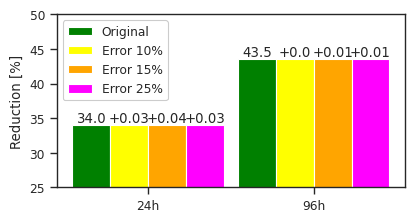

In [47]:
fig, ax = plt.subplots(figsize=(4.5,2.25))

# orig 24
width = 0.08
padding = 0.03
x = 2
y = 2.35

# 24h
orig_24 = ax.bar(x - width * 1.5, wf_res_24h_10[0], width, label='Original', color='green')
bar_24_10 = ax.bar(x - width * 0.5, wf_res_24h_10[1], width, label='Error 10%', color='yellow')
bar_24_15 = ax.bar(x + width * 0.5, wf_res_24h_15[1], width, label='Error 15%', color='orange')
bar_24_25 = ax.bar(x + width * 1.5, wf_res_24h_25[1], width, label='Error 25%', color='magenta')

ax.bar_label(orig_24, labels=[f'{round(wf_res_24h_10[0], 1)}'])
ax.bar_label(bar_24_10, labels=[f'+{round(wf_res_24h_10[1] - wf_res_24h_10[0], 2)}'])
ax.bar_label(bar_24_15, labels=[f'+{round(wf_res_24h_15[1] - wf_res_24h_10[0], 2)}'])
ax.bar_label(bar_24_25, labels=[f'+{round(wf_res_24h_25[1] - wf_res_24h_10[0], 2)}'])

# 96h
orig_96 = ax.bar(y - width * 1.5, wf_res_96h_10[0], width, label='Original', color='green')
bar_96_10 = ax.bar(y - width * 0.5, wf_res_96h_10[1], width, label='Error 10%', color='yellow')
bar_96_15 = ax.bar(y + width * 0.5, wf_res_96h_15[1], width, label='Error 15%', color='orange')
bar_96_25 = ax.bar(y + width * 1.5, wf_res_96h_25[1], width, label='Error 25%', color='magenta')

ax.bar_label(orig_96, labels=[f'{round(wf_res_96h_10[0], 1)}'])
ax.bar_label(bar_96_10, labels=[f'+{round(wf_res_96h_10[1] - wf_res_96h_10[0], 2)}'])
ax.bar_label(bar_96_15, labels=[f'+{round(wf_res_96h_15[1] - wf_res_96h_10[0], 2)}'])
ax.bar_label(bar_96_25, labels=[f'+{round(wf_res_96h_25[1] - wf_res_96h_10[0], 2)}'])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', ncols=1, framealpha=1)

xticks = [x, y]
xlabels = ['24h', '96h']
ax.set_xticks(xticks, xlabels)
ax.set_ylabel('Reduction [%]')
ax.set_ylim(25,50)

plt.savefig(f'../image/runtime-sensitivity-analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
# experiment on an  running docker (no k8s)
def percentage_inc(old, new):
    return ((new - old) / old) * 100

# K8S cluster of 3 nodes - rnaseq - test,docker on k8s
k8s_cont = (1767722805841, 1767723292055)
k8s_diff = k8s_cont[1] - k8s_cont[0]
k8s_int = (1767724247124, 1767724501000), (1767724659639, 1767724988000)
k8s_int_diff = k8s_int[0][1] - k8s_int[0][0] + k8s_int[1][1] - k8s_int[1][0]

print('rnaseq-test (<10 minutes)')
print(f'{k8s_diff/1000:.0f}s')
print(f'{k8s_int_diff/1000:.0f}s')
print(f'{percentage_inc(k8s_diff, k8s_int_diff):.2f}%')
print(f'{(k8s_int_diff - k8s_diff) / 1000:.0f}s')

rnaseq-test (<10 minutes)
486s
582s
19.75%
96s
